## Authors
Nick Calabro, Anthony Klimas, Luke MacVicar, Hilary Jaen Rodriguez


### Division of Labor
- Nick Calabro - Feature-level analysis
- Anthony Klimas - Data loading & inspection
- Luke MacVicar - Visualization 
- Hilary Jaen Rodriguez - Written interpretations, Preliminary plan for preprocessing




### Feature-level Analysis

#### Summary statistics (means, std, value counts)

**Mean:**   ```5798.286```

**Standard Deviation:**   ```5429.592```

**Value Counts**

| Category            | True Count | False Count |
|---------------------|-----------:|------------:|
| Infiltration        | 19,894     | 92,226      |
| Effusion            | 13,317     | 98,803      |
| Atelectasis         | 11,559     | 100,561     |
| Nodule              | 6,331      | 105,789     |
| Mass                | 5,782      | 106,338     |
| Pneumothorax        | 5,302      | 106,818     |
| Consolidation       | 4,667      | 107,453     |
| Pleural Thickening  | 3,385      | 108,735     |
| Cardiomegaly        | 2,776      | 109,344     |
| Emphysema           | 2,516      | 109,604     |
| Edema               | 2,303      | 109,817     |
| Fibrosis            | 1,686      | 110,434     |
| Pneumonia           | 1,431      | 110,689     |
| Hernia              | 227        | 111,893     |

#### Class distribution visualization



In [24]:
"""
NIH Chest X-ray 14 Metadata Inspection
Author: Nicholas J. Calabro 
"""

import pandas as pd

data_frame = pd.read_csv("../chest_xray_dataset/CXR8/Data_Entry_2017_v2020.csv")

data_frame    


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168
...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,38,M,PA,2048,2500,0.168,0.168
112116,00030802_000.png,No Finding,0,30802,28,M,PA,2048,2500,0.168,0.168
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168
112118,00030804_000.png,No Finding,0,30804,29,F,PA,2048,2500,0.168,0.168


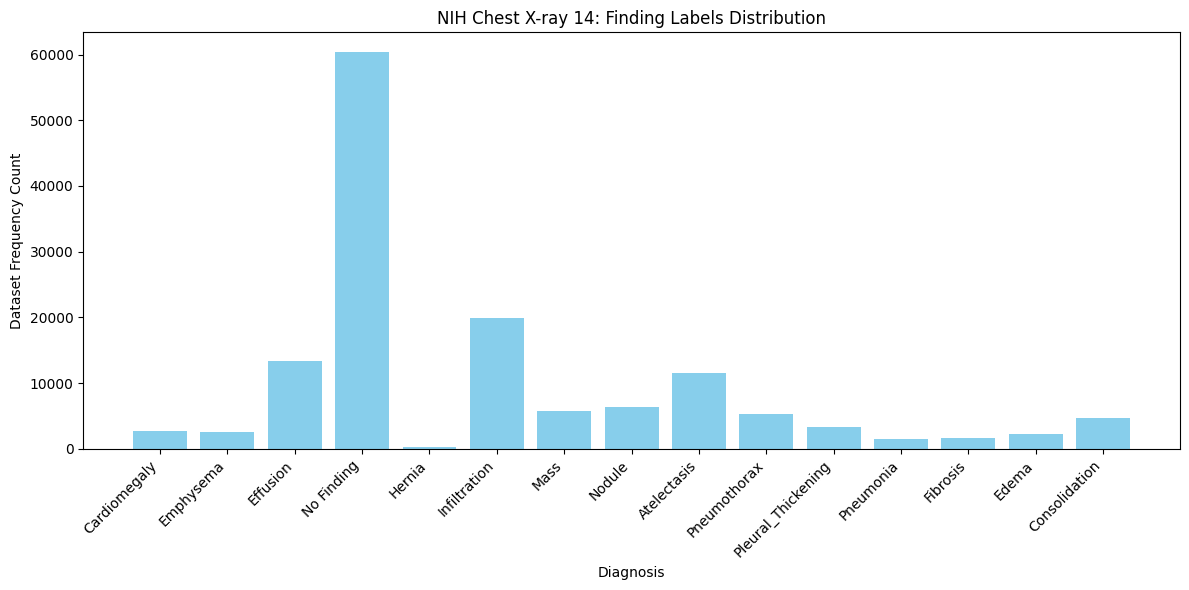

In [23]:
"""
NIH Chest X-ray 14 Metadata Distribution
Author: Nicholas J. Calabro 
"""

import matplotlib.pyplot as plt
from collections import Counter


# Find all labels
all_labels = []
for labels in data_frame['Finding Labels']:
    all_labels.extend([label.strip() for label in labels.split('|')])

# Count each label
label_counts = Counter(all_labels)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.title('NIH Chest X-ray 14: Finding Labels Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Dataset Frequency Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Missing values, outliers, duplicates

In terms of outliers, there may be entries that have skewed resolution. If we can select infiltration, effusion, or atelectasis entries with resolution that are irregular (aspect ratio "out of bounds" in particular may make a difference), we should opt to remove or ignore them to decrease the class imbalance.

Each patient and image is given an abstract ID so while there are duplicate patients, there are not duplicate image entries.